## 1. Project Setup and Raw Data Location

This section imports the required libraries and defines the project paths.

The feature engineering experiments will use the original raw dataset while keeping the existing processed data, trained models, and deployed Streamlit application unchanged.

The available raw data files are displayed first to verify the correct dataset before starting the experiments.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Project paths
PROJECT_ROOT = Path.cwd().parent
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)

print("\nAvailable raw files:")

for file in RAW_DATA_DIR.iterdir():
    print("-", file.name)

Project root: /media/mohamed/FCAI/NTI/NTI-Final-Project
Raw data directory: /media/mohamed/FCAI/NTI/NTI-Final-Project/data/raw

Available raw files:
- .gitkeep
- signal_metrics.csv


## 2. Load and Inspect the Raw Dataset

The original dataset is loaded to inspect its structure before applying any feature engineering.

This step verifies the dataset dimensions, column names, and the availability of the `Timestamp` feature that may contain useful temporal information.

No modifications are made to the original dataset at this stage.

In [17]:
# Load the raw dataset
df = pd.read_csv(RAW_DATA_DIR / "signal_metrics.csv")

print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Types:")
print(df.dtypes)

Dataset Shape: (16829, 12)

Columns:
['Timestamp', 'Locality', 'Latitude', 'Longitude', 'Signal Strength (dBm)', 'Signal Quality (%)', 'Data Throughput (Mbps)', 'Latency (ms)', 'Network Type', 'BB60C Measurement (dBm)', 'srsRAN Measurement (dBm)', 'BladeRFxA9 Measurement (dBm)']

First 5 Rows:


,Timestamp,Locality,Latitude,Longitude,Signal Strength (dBm),Signal Quality (%),Data Throughput (Mbps),Latency (ms),Network Type,BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm)
0,2023-05-05 12:50:40.000000,Anisabad,25.599109,85.137355,-84.274113,0.0,1.863890,129.122914,3G,0.000000,0.000000,0.000000
1,2023-05-05 12:53:47.210173,Fraser Road,25.433286,85.070053,-97.653121,0.0,5.132296,54.883606,4G,-95.810791,-105.452359,-99.920892
2,2023-05-05 12:56:54.420346,Boring Canal Road,25.498809,85.211371,-87.046134,0.0,1.176985,119.598286,LTE,-91.593861,-95.419482,-87.714070
3,2023-05-05 13:00:01.630519,Danapur,25.735138,85.208400,-94.143159,0.0,68.596932,46.598387,5G,-90.642773,-101.895905,-96.570698
4,2023-05-05 13:03:08.840692,Phulwari Sharif,25.538556,85.159860,-94.564765,0.0,38.292038,30.342828,5G,-90.489100,-103.318304,-95.102467



Data Types:
Timestamp                           str
Locality                            str
Latitude                        float64
Longitude                       float64
Signal Strength (dBm)           float64
Signal Quality (%)              float64
Data Throughput (Mbps)          float64
Latency (ms)                    float64
Network Type                        str
BB60C Measurement (dBm)         float64
srsRAN Measurement (dBm)        float64
BladeRFxA9 Measurement (dBm)    float64
dtype: object


## 3. Timestamp Feature Analysis

Before creating temporal features, the `Timestamp` column is converted to a proper datetime format and inspected.

This analysis determines the time range covered by the dataset and checks whether the timestamps contain sufficient variation in hours, days, and dates to support meaningful temporal feature engineering.

The original raw dataset remains unchanged because the analysis is performed on a copy of the data.

In [18]:
# Create a copy to keep the raw dataset unchanged
df_fe = df.copy()

# Convert Timestamp to datetime
df_fe["Timestamp"] = pd.to_datetime(
    df_fe["Timestamp"],
    errors="coerce"
)

print("Missing/Invalid Timestamps:", df_fe["Timestamp"].isna().sum())

print("\nTime Range:")
print("Start:", df_fe["Timestamp"].min())
print("End  :", df_fe["Timestamp"].max())

print("\nTimestamp Variation:")
print("Unique Dates       :", df_fe["Timestamp"].dt.date.nunique())
print("Unique Hours       :", df_fe["Timestamp"].dt.hour.nunique())
print("Unique Days of Week:", df_fe["Timestamp"].dt.dayofweek.nunique())

print("\nRecords by Hour:")
print(
    df_fe["Timestamp"]
    .dt.hour
    .value_counts()
    .sort_index()
)

Missing/Invalid Timestamps: 0

Time Range:
Start: 2023-05-05 12:50:40
End  : 2023-06-10 23:56:52.791244

Timestamp Variation:
Unique Dates       : 37
Unique Hours       : 24
Unique Days of Week: 7

Records by Hour:
Timestamp
0     692
1     693
2     692
3     693
4     691
5     693
6     692
7     693
8     691
9     693
10    692
11    693
12    695
13    712
14    711
15    712
16    711
17    712
18    711
19    712
20    711
21    712
22    711
23    711
Name: count, dtype: int64


## 4. Temporal Patterns in Data Throughput

Before adding temporal features to the regression models, the relationship between time and data throughput is investigated.

The average and median throughput are analyzed across different hours of the day and days of the week.

This step helps determine whether the timestamp contains useful predictive information rather than adding temporal features without evidence.

Throughput by Hour:


,mean,median,count
Timestamp,,,
0,16.686514,3.668728,692
1,16.863700,3.611330,693
2,15.445494,3.175792,692
3,15.793719,3.001694,693
4,15.807955,2.914012,691
5,15.689967,2.994460,693
6,18.245713,3.351514,692
7,16.188500,3.602201,693
8,15.572779,2.985366,691


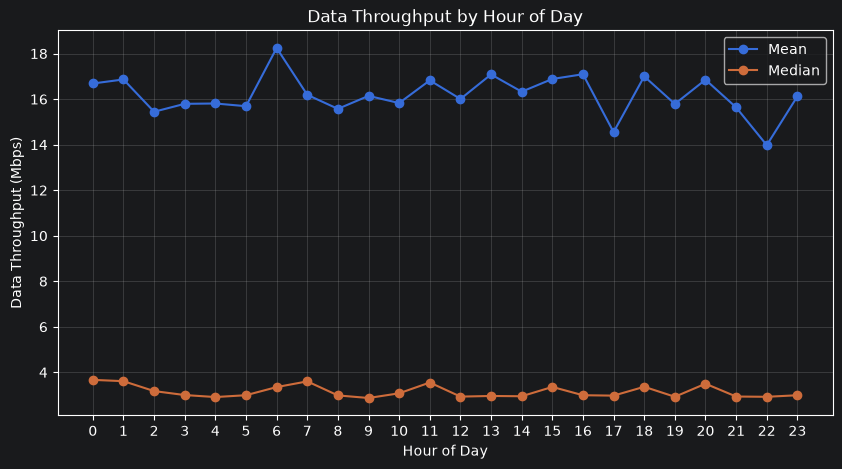


Throughput by Day of Week:


,mean,median,count
DayOfWeek,,,
Monday,15.143438,2.998790,2308
Tuesday,16.820812,3.158920,2307
Wednesday,16.609450,3.242517,2308
Thursday,15.510160,2.925815,2307
Friday,16.226913,3.363855,2523
Saturday,16.394692,2.967783,2769
Sunday,16.528243,2.989259,2307


In [19]:
# Average and median throughput by hour
hourly_throughput = (
    df_fe
    .groupby(df_fe["Timestamp"].dt.hour)["Data Throughput (Mbps)"]
    .agg(["mean", "median", "count"])
)

print("Throughput by Hour:")
display(hourly_throughput)


# Plot average throughput by hour
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_throughput.index,
    hourly_throughput["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    hourly_throughput.index,
    hourly_throughput["median"],
    marker="o",
    label="Median"
)

plt.xlabel("Hour of Day")
plt.ylabel("Data Throughput (Mbps)")
plt.title("Data Throughput by Hour of Day")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.show()


# Average and median throughput by day of week
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df_fe["DayOfWeek"] = df_fe["Timestamp"].dt.dayofweek

daily_throughput = (
    df_fe
    .groupby("DayOfWeek")["Data Throughput (Mbps)"]
    .agg(["mean", "median", "count"])
)

daily_throughput.index = daily_throughput.index.map(day_names)

print("\nThroughput by Day of Week:")
display(daily_throughput)

## 5. Temporal Patterns by Network Type

The overall hourly throughput pattern shows relatively limited variation across the day.

However, aggregating all network technologies together may hide temporal patterns within individual network types.

This section analyzes hourly throughput separately for each network type to determine whether temporal information becomes more informative when considering 3G, 4G, and 5G independently.

Average Throughput by Hour and Network Type:


Network Type,3G,4G,5G,LTE
Hour,,,,
0,1.99,6.60,52.77,2.06
1,2.07,6.67,53.93,1.98
2,1.90,6.42,54.16,1.91
3,2.07,6.47,53.82,1.96
4,1.99,6.72,54.03,1.97
5,1.99,6.56,51.36,1.98
6,1.97,6.37,59.15,2.01
7,2.03,6.27,52.78,1.91
8,2.02,6.50,52.61,2.01


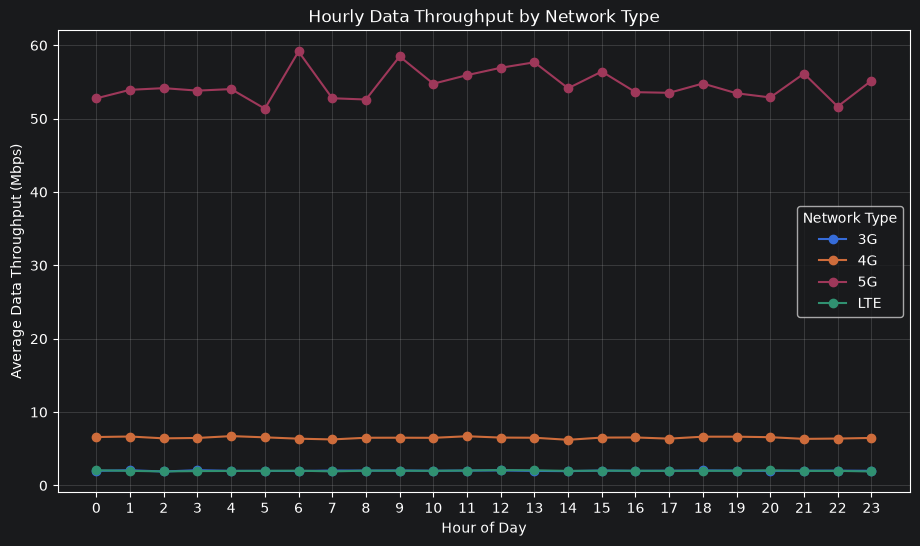

In [20]:
# Extract hour from Timestamp
df_fe["Hour"] = df_fe["Timestamp"].dt.hour

# Calculate average throughput by hour and network type
hour_network_throughput = (
    df_fe
    .groupby(["Hour", "Network Type"])["Data Throughput (Mbps)"]
    .mean()
    .unstack()
)

print("Average Throughput by Hour and Network Type:")
display(hour_network_throughput.round(2))


# Visualize hourly throughput for each network type
plt.figure(figsize=(11, 6))

for network_type in hour_network_throughput.columns:
    plt.plot(
        hour_network_throughput.index,
        hour_network_throughput[network_type],
        marker="o",
        label=network_type
    )

plt.xlabel("Hour of Day")
plt.ylabel("Average Data Throughput (Mbps)")
plt.title("Hourly Data Throughput by Network Type")
plt.xticks(range(24))
plt.legend(title="Network Type")
plt.grid(alpha=0.3)

plt.show()

## 6. Throughput Variation Within Network Types

The temporal analysis showed that hour of day does not provide a strong or consistent throughput pattern.

The next step is to investigate the variation in throughput within each network technology.

This analysis is particularly important for 5G, where the regression models tend to predict values near the average 5G throughput even when the actual throughput varies considerably.

Understanding within-group variation can help identify which existing features may be useful for feature engineering.

In [21]:
# Throughput distribution statistics for each network type
network_stats = (
    df_fe
    .groupby("Network Type")["Data Throughput (Mbps)"]
    .agg([
        "count",
        "mean",
        "median",
        "std",
        "min",
        "max"
    ])
)

print("Throughput Statistics by Network Type:")
display(network_stats.round(2))


# Correlation analysis within each network type
features_to_check = [
    "Signal Strength (dBm)",
    "Latency (ms)",
    "Latitude",
    "Longitude",
    "Data Throughput (Mbps)"
]

for network_type in df_fe["Network Type"].unique():

    subset = df_fe[
        df_fe["Network Type"] == network_type
    ][features_to_check]

    correlations = (
        subset
        .corr()["Data Throughput (Mbps)"]
        .drop("Data Throughput (Mbps)")
        .sort_values(ascending=False)
    )

    print(f"\n{network_type} - Correlation with Throughput:")
    display(correlations.to_frame("Correlation"))

Throughput Statistics by Network Type:


,count,mean,median,std,min,max
Network Type,,,,,,
3G,4208,2.01,2.01,0.58,1.00,3.00
4G,4219,6.50,6.51,2.03,3.00,10.00
5G,4178,54.58,54.69,26.09,10.02,99.99
LTE,4224,1.99,2.00,0.58,1.00,3.00



3G - Correlation with Throughput:


,Correlation
Longitude,0.019913
Signal Strength (dBm),0.015431
Latitude,0.013491
Latency (ms),-0.006522



4G - Correlation with Throughput:


,Correlation
Signal Strength (dBm),0.027050
Longitude,0.008926
Latency (ms),-0.001707
Latitude,-0.003788



LTE - Correlation with Throughput:


,Correlation
Latitude,0.027680
Longitude,0.016565
Latency (ms),0.016143
Signal Strength (dBm),0.003689



5G - Correlation with Throughput:


,Correlation
Latency (ms),0.009929
Latitude,-0.003578
Longitude,-0.021149
Signal Strength (dBm),-0.025197


## 7. Predictability Analysis Within 5G

The previous analysis showed substantial throughput variation within the 5G observations, ranging from approximately 10 Mbps to 100 Mbps.

However, individual numerical features showed almost no linear correlation with throughput within the 5G subset.

To determine whether the available features contain useful nonlinear predictive information, a separate regression experiment is performed using only 5G observations.

This experiment helps distinguish between a limitation of the regression models and a limitation of the information available in the dataset.

In [23]:
# Select only 5G observations
df_5g = df_fe[df_fe["Network Type"] == "5G"].copy()

features_5g = [
    "Locality",
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)"
]

target = "Data Throughput (Mbps)"

X_5g = df_5g[features_5g]
y_5g = df_5g[target]


# Same train/test strategy
X_train_5g, X_test_5g, y_train_5g, y_test_5g = train_test_split(
    X_5g,
    y_5g,
    test_size=0.2,
    random_state=42
)


# Preprocessing
categorical_features = ["Locality"]

preprocessor_5g = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)


# Nonlinear model
model_5g = Pipeline([
    ("preprocessor", preprocessor_5g),
    (
        "model",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        )
    )
])


# Train
model_5g.fit(X_train_5g, y_train_5g)


# Predict
y_pred_5g = model_5g.predict(X_test_5g)


# Evaluate
mae_5g = mean_absolute_error(y_test_5g, y_pred_5g)
rmse_5g = np.sqrt(
    mean_squared_error(y_test_5g, y_pred_5g)
)
r2_5g = r2_score(y_test_5g, y_pred_5g)


print("5G-Only Prediction Performance")
print("-" * 35)
print(f"MAE  : {mae_5g:.4f}")
print(f"RMSE : {rmse_5g:.4f}")
print(f"R²   : {r2_5g:.4f}")

5G-Only Prediction Performance
-----------------------------------
MAE  : 23.5707
RMSE : 27.4016
R²   : -0.0713


## 8. Investigation of Measurement Features

The 5G-only prediction experiment produced a negative R² score, indicating that the currently selected features provide limited predictive information for explaining throughput variation within 5G observations.

Before creating artificial interaction features, the original measurement columns are investigated to determine whether they contain additional information that was excluded during preprocessing.

The analysis focuses on their relationship with signal strength and data throughput, particularly within the 5G subset.

No changes are made to the existing preprocessing pipeline or deployed models.

In [24]:
measurement_cols = [
    "BB60C Measurement (dBm)",
    "srsRAN Measurement (dBm)",
    "BladeRFxA9 Measurement (dBm)"
]

analysis_cols = [
    "Signal Strength (dBm)",
    *measurement_cols,
    "Data Throughput (Mbps)"
]


# Overall correlation
print("Overall Correlations:")
display(
    df_fe[analysis_cols]
    .corr()
    .round(4)
)


# 5G-only correlation with throughput
df_5g = df_fe[df_fe["Network Type"] == "5G"]

measurement_corr_5g = (
    df_5g[analysis_cols]
    .corr()["Data Throughput (Mbps)"]
    .drop("Data Throughput (Mbps)")
    .sort_values(ascending=False)
)

print("\n5G - Correlation with Throughput:")
display(
    measurement_corr_5g.to_frame("Correlation").round(4)
)


# Check whether measurement columns are essentially copies
# or transformations of Signal Strength
print("\nDifference from Signal Strength:")

for col in measurement_cols:

    difference = (
        df_fe[col] -
        df_fe["Signal Strength (dBm)"]
    )

    print(f"\n{col}")
    print(f"Mean difference : {difference.mean():.4f}")
    print(f"Std difference  : {difference.std():.4f}")
    print(f"Min difference  : {difference.min():.4f}")
    print(f"Max difference  : {difference.max():.4f}")

Overall Correlations:


,Signal Strength (dBm),BB60C Measurement (dBm),srsRAN Measurement (dBm),BladeRFxA9 Measurement (dBm),Data Throughput (Mbps)
Signal Strength (dBm),1.0000,0.6217,0.6170,0.6226,-0.4838
BB60C Measurement (dBm),0.6217,1.0000,0.9976,0.9974,-0.3581
srsRAN Measurement (dBm),0.6170,0.9976,1.0000,0.9988,-0.3556
BladeRFxA9 Measurement (dBm),0.6226,0.9974,0.9988,1.0000,-0.3585
Data Throughput (Mbps),-0.4838,-0.3581,-0.3556,-0.3585,1.0000



5G - Correlation with Throughput:


,Correlation
Signal Strength (dBm),-0.0252
srsRAN Measurement (dBm),-0.0264
BladeRFxA9 Measurement (dBm),-0.0268
BB60C Measurement (dBm),-0.0358



Difference from Signal Strength:

BB60C Measurement (dBm)
Mean difference : 21.2523
Std difference  : 36.9327
Min difference  : -4.9992
Max difference  : 95.4188

srsRAN Measurement (dBm)
Mean difference : 15.6329
Std difference  : 40.1096
Min difference  : -10.0000
Max difference  : 95.4188

BladeRFxA9 Measurement (dBm)
Mean difference : 21.2526
Std difference  : 36.8781
Min difference  : -2.9999
Max difference  : 95.4188


## 9. Nonlinear Feature Dependency Analysis

Linear correlation analysis showed very weak relationships between the available numerical features and throughput within the 5G subset.

However, Pearson correlation primarily measures linear relationships and may fail to detect nonlinear dependencies.

Mutual Information is therefore used to investigate whether the available features contain nonlinear predictive information about 5G throughput.

This analysis helps determine whether further feature engineering from the existing variables is likely to improve model performance.

In [25]:
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import OneHotEncoder


# Select 5G observations
df_5g = df_fe[df_fe["Network Type"] == "5G"].copy()

numeric_features_5g = [
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)",
    "BB60C Measurement (dBm)",
    "srsRAN Measurement (dBm)",
    "BladeRFxA9 Measurement (dBm)"
]

X_mi = df_5g[numeric_features_5g]
y_mi = df_5g["Data Throughput (Mbps)"]


# Calculate Mutual Information
mi_scores = mutual_info_regression(
    X_mi,
    y_mi,
    random_state=42
)

mi_results = pd.DataFrame({
    "Feature": numeric_features_5g,
    "Mutual Information": mi_scores
}).sort_values(
    "Mutual Information",
    ascending=False
)

print("5G - Nonlinear Dependency with Throughput:")
display(mi_results)

5G - Nonlinear Dependency with Throughput:


,Feature,Mutual Information
3,Latency (ms),0.024553
4,BB60C Measurement (dBm),0.014011
0,Latitude,0.006717
2,Signal Strength (dBm),0.000000
1,Longitude,0.000000
5,srsRAN Measurement (dBm),0.000000
6,BladeRFxA9 Measurement (dBm),0.000000


## 10. Interaction and Nonlinear Feature Engineering

The previous analyses showed limited linear and nonlinear dependency between the available features and throughput within the 5G subset.

As a final feature engineering experiment, several interaction and nonlinear features are created from signal strength and latency.

The purpose of this experiment is to test whether combinations of the existing variables provide predictive information that is not captured by the original features individually.

The existing production models and deployed application remain unchanged.

In [26]:
# Create a new experimental copy
df_exp = df_fe.copy()

# Interaction and nonlinear features
df_exp["Signal_Latency_Interaction"] = (
    df_exp["Signal Strength (dBm)"] *
    df_exp["Latency (ms)"]
)

df_exp["Signal_Squared"] = (
    df_exp["Signal Strength (dBm)"] ** 2
)

df_exp["Latency_Squared"] = (
    df_exp["Latency (ms)"] ** 2
)

df_exp["Signal_Latency_Ratio"] = (
    df_exp["Signal Strength (dBm)"] /
    (df_exp["Latency (ms)"] + 1)
)

engineered_features = [
    "Signal_Latency_Interaction",
    "Signal_Squared",
    "Latency_Squared",
    "Signal_Latency_Ratio"
]

print("Engineered Features Created:")

display(
    df_exp[
        [
            "Signal Strength (dBm)",
            "Latency (ms)",
            *engineered_features
        ]
    ].head()
)

print("\nMissing Values:")
print(df_exp[engineered_features].isna().sum())

print("\nInfinite Values:")
print(
    np.isinf(
        df_exp[engineered_features]
    ).sum()
)

Engineered Features Created:


,Signal Strength (dBm),Latency (ms),Signal_Latency_Interaction,Signal_Squared,Latency_Squared,Signal_Latency_Ratio
0,-84.274113,129.122914,-10881.719071,7102.126153,16672.726925,-0.647650
1,-97.653121,54.883606,-5359.555387,9536.132037,3012.210175,-1.747438
2,-87.046134,119.598286,-10410.568412,7577.029389,14303.750072,-0.721786
3,-94.143159,46.598387,-4386.919340,8862.934310,2171.409673,-1.977864
4,-94.564765,30.342828,-2869.362355,8942.494715,920.687190,-3.017110



Missing Values:
Signal_Latency_Interaction    0
Signal_Squared                0
Latency_Squared               0
Signal_Latency_Ratio          0
dtype: int64

Infinite Values:
Signal_Latency_Interaction    0
Signal_Squared                0
Latency_Squared               0
Signal_Latency_Ratio          0
dtype: int64


## 11. Original vs. Engineered Feature Comparison

To evaluate whether the newly created interaction and nonlinear features improve predictive performance, two Random Forest models are compared using the same 5G observations.

The first model uses only the original features, while the second model uses the original features together with the engineered features.

Both models use the same train/test split, preprocessing strategy, model configuration, and random state. Therefore, any performance difference can be attributed to the additional engineered features rather than changes in the model or evaluation setup.

In [27]:
# Select only 5G observations
df_5g_exp = df_exp[df_exp["Network Type"] == "5G"].copy()

# Original features
original_features = [
    "Locality",
    "Latitude",
    "Longitude",
    "Signal Strength (dBm)",
    "Latency (ms)"
]

# Original + engineered features
enhanced_features = original_features + [
    "Signal_Latency_Interaction",
    "Signal_Squared",
    "Latency_Squared",
    "Signal_Latency_Ratio"
]

target = "Data Throughput (Mbps)"


# --------------------------------------------------
# Use the SAME train/test indices for both experiments
# --------------------------------------------------

train_idx, test_idx = train_test_split(
    df_5g_exp.index,
    test_size=0.2,
    random_state=42
)

y_train = df_5g_exp.loc[train_idx, target]
y_test = df_5g_exp.loc[test_idx, target]


# --------------------------------------------------
# Helper function
# --------------------------------------------------

def evaluate_feature_set(feature_list):

    X_train = df_5g_exp.loc[train_idx, feature_list]
    X_test = df_5g_exp.loc[test_idx, feature_list]

    categorical_features = ["Locality"]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "cat",
                OneHotEncoder(handle_unknown="ignore"),
                categorical_features
            )
        ],
        remainder="passthrough"
    )

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    return {
        "MAE": mean_absolute_error(y_test, predictions),
        "RMSE": np.sqrt(mean_squared_error(y_test, predictions)),
        "R²": r2_score(y_test, predictions)
    }


# --------------------------------------------------
# Evaluate both feature sets
# --------------------------------------------------

original_results = evaluate_feature_set(original_features)
engineered_results = evaluate_feature_set(enhanced_features)


comparison = pd.DataFrame({
    "Original Features": original_results,
    "Original + Engineered": engineered_results
}).T


print("5G Feature Engineering Comparison:")
display(comparison.round(4))


# Calculate improvement
print("\nChange after Feature Engineering:")
print(
    f"MAE  : "
    f"{engineered_results['MAE'] - original_results['MAE']:+.4f}"
)

print(
    f"RMSE : "
    f"{engineered_results['RMSE'] - original_results['RMSE']:+.4f}"
)

print(
    f"R²   : "
    f"{engineered_results['R²'] - original_results['R²']:+.4f}"
)

5G Feature Engineering Comparison:


,MAE,RMSE,R²
Original Features,23.5707,27.4016,-0.0713
Original + Engineered,23.6364,27.3566,-0.0678



Change after Feature Engineering:
MAE  : +0.0657
RMSE : -0.0450
R²   : +0.0035


## 12. Feature Engineering Findings and Conclusion

The feature engineering investigation was conducted to determine whether additional information could improve throughput prediction without changing the regression models.

### Key Findings

- The `Timestamp` feature covers 37 days, all 24 hours, and all 7 days of the week.
- Hourly analysis showed no strong or consistent relationship between time of day and data throughput.
- Network type was found to be a major factor separating throughput levels:
  - 3G throughput is approximately 2 Mbps.
  - LTE throughput is approximately 2 Mbps.
  - 4G throughput is approximately 6.5 Mbps.
  - 5G throughput has a much wider range, approximately 10–100 Mbps.
- Within the 5G subset, the available numerical features showed very weak linear correlations with throughput.
- Mutual Information analysis also showed very limited nonlinear dependency between the available numerical features and 5G throughput.
- A 5G-only Random Forest experiment achieved an R² of approximately -0.07, indicating that the available features could not reliably explain the variation in 5G throughput.
- Additional interaction and nonlinear features were tested:
  - Signal × Latency
  - Signal²
  - Latency²
  - Signal / (Latency + 1)
- These engineered features produced only negligible changes in performance:
  - MAE change: +0.0657
  - RMSE change: -0.0450
  - R² change: +0.0035

### Conclusion

The experiments indicate that simple feature engineering based on the currently available variables does not provide a meaningful improvement in predictive performance.

The main limitation appears to be the amount of predictive information available in the dataset, particularly for explaining the large variation in throughput within 5G observations.

Therefore, the existing production models and deployed Streamlit application are kept unchanged.

Future improvements would likely require additional network measurements or contextual features that better explain within-network throughput variation rather than simply increasing model complexity.